### Uploading Data

To upload your dataset, run the next cell and follow the prompts to select your file.

In [1]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

Saving wa-police-force-crime-timeseries.xlsx to wa-police-force-crime-timeseries.xlsx


In [2]:
df= pd.read_excel('wa-police-force-crime-timeseries.xlsx', sheet_name='Origin_Data')
df['Month-Year'] = df['Month-Year'].dt.to_period('M')
df.head(6)

,Month-Year,Stealing of Motor Vehicle
0,2022-04,551
1,2022-05,547
2,2022-06,491
3,2022-07,450
4,2022-08,551
5,2022-09,492


In [3]:
df.shape

(48, 2)

In [4]:
print(df.dtypes)
df.info()

Month-Year                   period[M]
Stealing of Motor Vehicle        int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype    
---  ------                     --------------  -----    
 0   Month-Year                 48 non-null     period[M]
 1   Stealing of Motor Vehicle  48 non-null     int64    
dtypes: int64(1), period[M](1)
memory usage: 900.0 bytes


### Trend and Seasonality Analysis

To understand the patterns in 'Stealing of Motor Vehicle' over time, we'll create a line plot. This will help us visually identify any overall trends (e.g., increasing or decreasing numbers) and seasonal fluctuations (e.g., consistent patterns within a year).

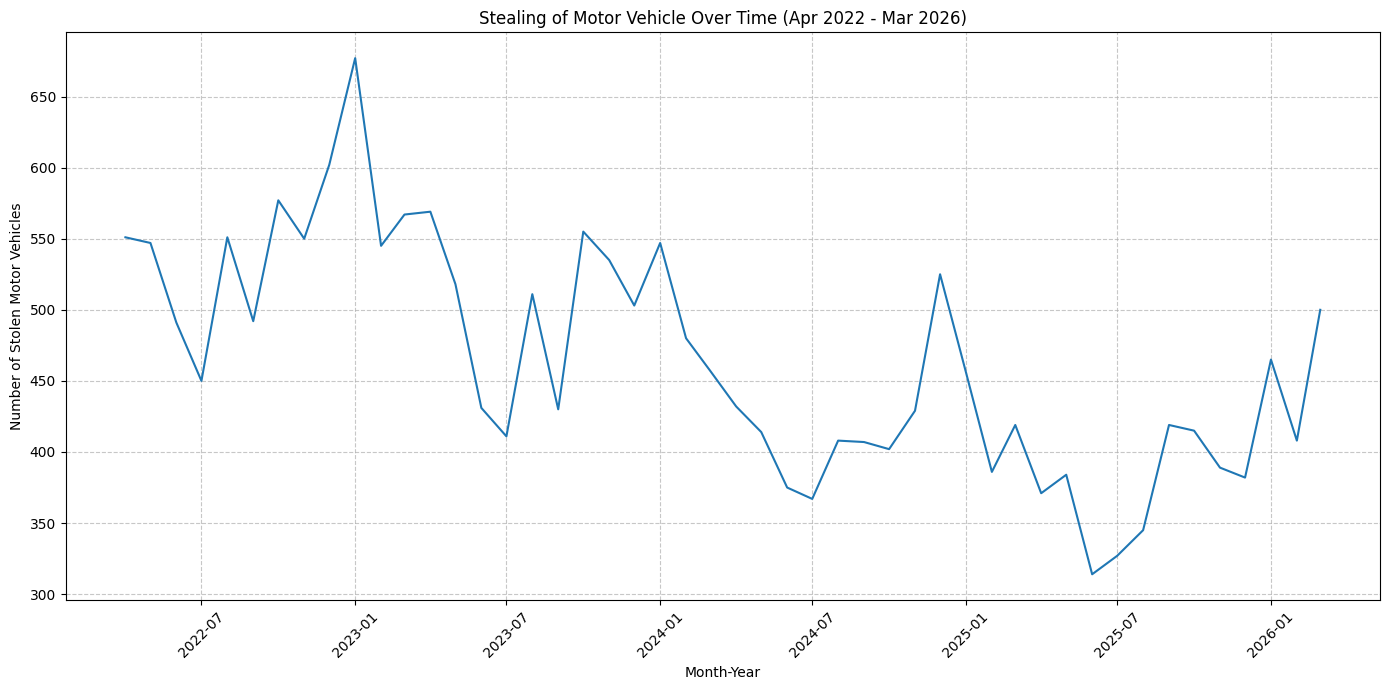

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Month-Year' from Period to Timestamp for plotting
df_plot = df.copy()
df_plot['Month-Year'] = df_plot['Month-Year'].dt.to_timestamp()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Month-Year', y='Stealing of Motor Vehicle', data=df_plot)
plt.title('Stealing of Motor Vehicle Over Time (Apr 2022 - Mar 2026)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Stolen Motor Vehicles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

From the plot, we can observe:

*   **Trend:** There appears to be a general downward trend in the number of 'Stealing of Motor Vehicle' incidents, particularly noticeable from mid-2023 onwards.
*   **Seasonality:** While the overall trend is decreasing, there seem to be some recurring patterns within each year. For instance, there might be peaks and troughs at similar times each year, suggesting a seasonal component. Further analysis would be needed to confirm specific seasonal patterns (e.g., using decomposition techniques).

In [6]:
df_dup=df.copy()

### Data Splitting: Training and Test Sets

We will now split the dataset into a training set and a test set. The last 12 months of observations will be reserved as the test set to evaluate the performance of any future models on unseen data, while all preceding observations will form the training set.

In [7]:
#Split data
train_set = df_dup.iloc[:-12].copy()
test_set = df_dup.iloc[-12:].copy()

print("Data successfully split")
print(f"Number of months in Training set: {len(train_set)}")
print(f"Number of months in Test set: {len(test_set)}")

Data successfully split
Number of months in Training set: 36
Number of months in Test set: 12


In [8]:
#3. Prophet
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare the training data for Prophet
# Prophet requires the dataframe to have columns named 'ds' (datestamp) and 'y' (value)
prophet_df = train_set[['Month-Year', 'Stealing of Motor Vehicle']].rename(columns={'Month-Year': 'ds', 'Stealing of Motor Vehicle': 'y'})
# Convert 'ds' column to datetime objects, as Prophet requires this.
prophet_df['ds'] = prophet_df['ds'].dt.to_timestamp()

# --- Model 1: Additive Seasonality ---
print("\n--- Prophet Model with Additive Seasonality ---")
# Initialize Prophet model with additive seasonality
model_additive = Prophet(seasonality_mode='additive', yearly_seasonality=True)
# Fit the model to the training data
model_additive.fit(prophet_df)

# Create a future DataFrame for 12 months (one year) of forecasting
future_additive = model_additive.make_future_dataframe(periods=12, freq='MS') # 'MS' for month frequency

# Make predictions
forecast_additive = model_additive.predict(future_additive)

# --- Model 2: Multiplicative Seasonality ---
print("\n--- Prophet Model with Multiplicative Seasonality ---")
# Initialize Prophet model with multiplicative seasonality
model_multiplicative = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True)
# Fit the model to the training data
model_multiplicative.fit(prophet_df)

# Create a future DataFrame for 12 months (one year) of forecasting
future_multiplicative = model_multiplicative.make_future_dataframe(periods=12, freq='MS')

# Make predictions
forecast_multiplicative = model_multiplicative.predict(future_multiplicative)

# Prepare actual values for comparison
actual_test_values = test_set['Stealing of Motor Vehicle'].values

# --- Evaluate Additive Model ---
# Out-of-sample RMSE (test set)
forecast_additive_test = forecast_additive['yhat'].iloc[-12:].values
rmse_additive_out_of_sample = np.sqrt(mean_squared_error(actual_test_values, forecast_additive_test))

# In-sample RMSE (training set)
# Align training data with prophet's forecast for the training period
prophet_training_y = prophet_df['y'].values
# We need to filter forecast_additive to only include dates present in the training set
forecast_additive_train_period = forecast_additive[forecast_additive['ds'].isin(prophet_df['ds'])]
prophet_forecast_additive_training_yhat = forecast_additive_train_period['yhat'].values
rmse_additive_in_sample = np.sqrt(mean_squared_error(prophet_training_y, prophet_forecast_additive_training_yhat))


# --- Evaluate Multiplicative Model ---
# Out-of-sample RMSE (test set)
forecast_multiplicative_test = forecast_multiplicative['yhat'].iloc[-12:].values
rmse_multiplicative_out_of_sample = np.sqrt(mean_squared_error(actual_test_values, forecast_multiplicative_test))

# In-sample RMSE (training set)
# We need to filter forecast_multiplicative to only include dates present in the training set
forecast_multiplicative_train_period = forecast_multiplicative[forecast_multiplicative['ds'].isin(prophet_df['ds'])]
prophet_forecast_multiplicative_training_yhat = forecast_multiplicative_train_period['yhat'].values
rmse_multiplicative_in_sample = np.sqrt(mean_squared_error(prophet_training_y, prophet_forecast_multiplicative_training_yhat))

# Display Results
print("\n--- RMSE Metrics ---")
print(f"Additive Model In-sample RMSE: {rmse_additive_in_sample:,.2f}")
print(f"Additive Model Out-of-sample RMSE: {rmse_additive_out_of_sample:,.2f}")
print(f"Multiplicative Model In-sample RMSE: {rmse_multiplicative_in_sample:,.2f}")
print(f"Multiplicative Model Out-of-sample RMSE: {rmse_multiplicative_out_of_sample:,.2f}")

# Determine the better model based on out-of-sample RMSE
if rmse_additive_out_of_sample <= rmse_multiplicative_out_of_sample:
    best_prophet_model = model_additive
    best_forecast = forecast_additive
    model_type = 'Additive'
    print(f"\nChosen Model: Prophet with {model_type} Seasonality (Lower Out-of-Sample RMSE)")
else:
    best_prophet_model = model_multiplicative
    best_forecast = forecast_multiplicative
    model_type = 'Multiplicative'
    print(f"\nChosen Model: Prophet with {model_type} Seasonality (Lower Out-of-Sample RMSE)")


--- Prophet Model with Additive Seasonality ---


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Prophet Model with Multiplicative Seasonality ---

--- RMSE Metrics ---
Additive Model In-sample RMSE: 12.83
Additive Model Out-of-sample RMSE: 75.43
Multiplicative Model In-sample RMSE: 11.65
Multiplicative Model Out-of-sample RMSE: 65.24

Chosen Model: Prophet with Multiplicative Seasonality (Lower Out-of-Sample RMSE)


### Visualizing Forecasts and Model Components

Now we will visualize the forecasts from both the additive and multiplicative Prophet models. This will allow us to visually inspect how well each model captures the historical data and projects into the future. After comparing the overall forecasts, we will delve into the individual components (trend and seasonality) of the better-performing model.

In [9]:
import matplotlib.pyplot as plt
from prophet.plot import plot_plotly, plot_components_plotly

# Prepare test data in Prophet format for plotting actuals
test_df_prophet = test_set[['Month-Year', 'Stealing of Motor Vehicle']].rename(columns={'Month-Year': 'ds', 'Stealing of Motor Vehicle': 'y'})
test_df_prophet['ds'] = test_df_prophet['ds'].dt.to_timestamp()


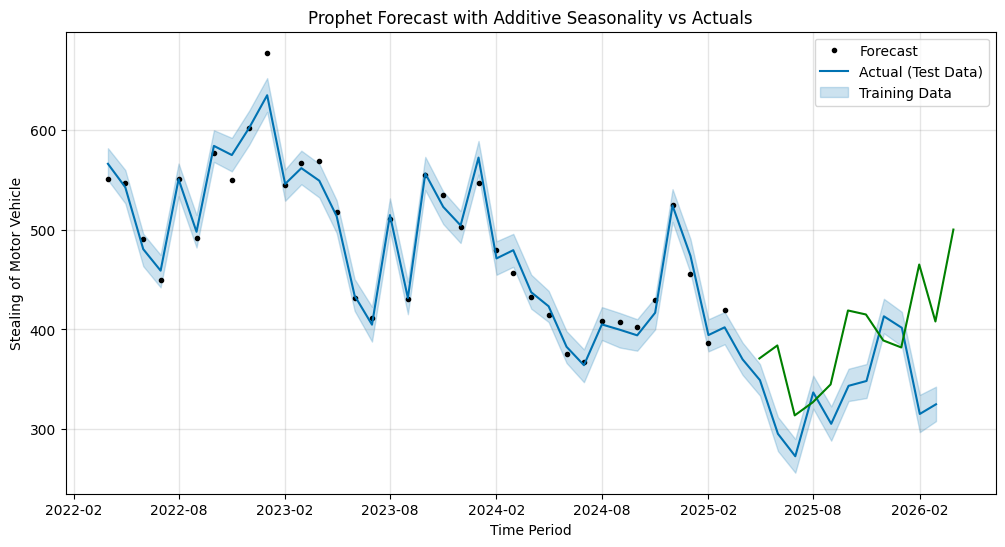

In [10]:
# --- Plot Additive Forecast vs Actuals ---
fig, ax = plt.subplots(figsize=(12, 6))
model_additive.plot(forecast_additive, ax=ax)
ax.plot(test_set['Month-Year'], test_set['Stealing of Motor Vehicle'], label='Actual (Test Data)', color='green')
ax.set_title('Prophet Forecast with Additive Seasonality vs Actuals')
ax.set_xlabel('Time Period')
ax.set_ylabel('Stealing of Motor Vehicle')
ax.legend(['Forecast', 'Actual (Test Data)', 'Training Data'])
plt.show()

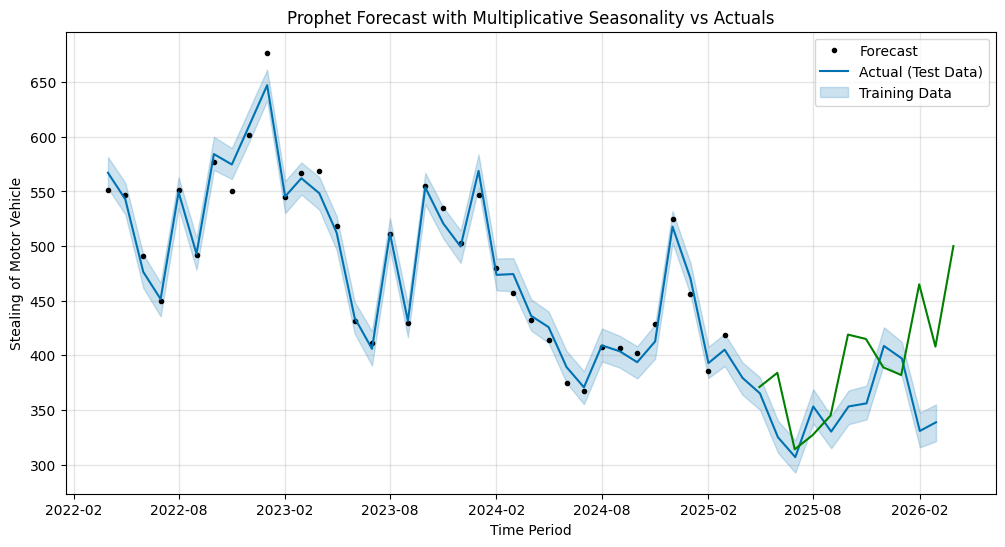

In [11]:
# --- Plot Multiplicative Forecast vs Actuals ---
fig, ax = plt.subplots(figsize=(12, 6))
model_multiplicative.plot(forecast_multiplicative, ax=ax)
ax.plot(test_set['Month-Year'], test_set['Stealing of Motor Vehicle'], label='Actual (Test Data)', color='green')
ax.set_title('Prophet Forecast with Multiplicative Seasonality vs Actuals')
ax.set_xlabel('Time Period')
ax.set_ylabel('Stealing of Motor Vehicle')
ax.legend(['Forecast', 'Actual (Test Data)', 'Training Data'])
plt.show()

### Seasonality and Trend Plots (for the best model)

Let's visualize the components (trend, yearly seasonality, and weekly seasonality if applicable) of the model that performed better based on the out-of-sample RMSE. This will help in understanding the underlying patterns identified by Prophet.

Displaying components for the Multiplicative Prophet Model:


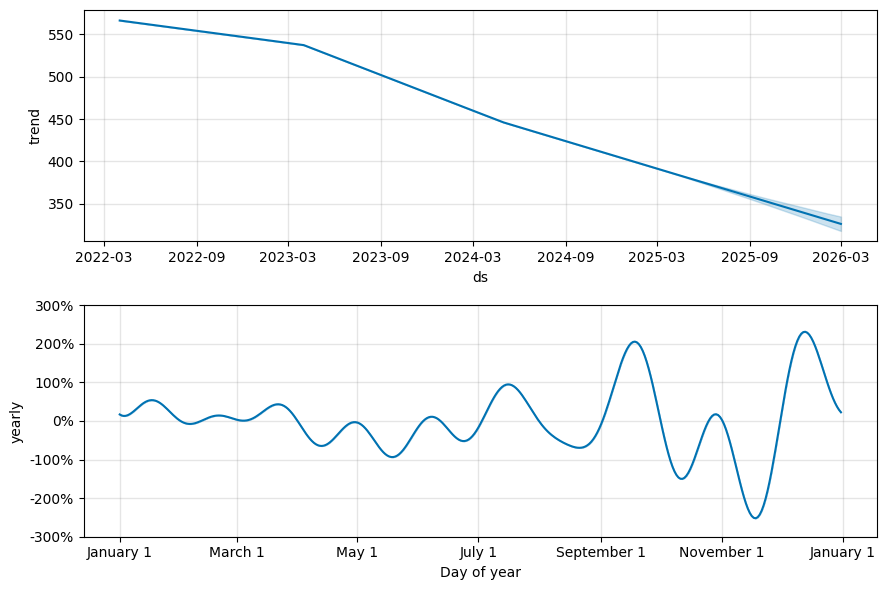

In [12]:
import matplotlib.pyplot as plt

# The variable storing the best model type is 'model_type', not 'best_model_name'.
# The variable storing the best model object is 'best_prophet_model', not 'best_model'.

if model_type == 'Additive':
    print("Displaying components for the Additive Prophet Model:")
    fig_components = best_prophet_model.plot_components(best_forecast)
else:
    print("Displaying components for the Multiplicative Prophet Model:")
    fig_components = best_prophet_model.plot_components(best_forecast)

plt.show()

### Interpretation of Trend and Seasonality

*   **Trend Component:** The trend plot shows the overall long-term direction of the 'Stealing of Motor Vehicle' incidents. A decreasing trend suggests that the number of incidents has been generally falling over the observed period.
*   **Yearly Seasonality:** The yearly seasonality plot illustrates recurring patterns within a year. Peaks and troughs in this plot indicate months where the incidents are typically higher or lower than the yearly average, respectively. This can inform forecasting by identifying predictable annual fluctuations.

These components directly impact forecasting decisions. The trend helps in predicting the general future direction, while seasonality allows for more accurate short-term predictions by accounting for regular, cyclical changes. For example, if there's a strong yearly seasonality with higher incidents in particular months, the forecast will reflect these anticipated increases or decreases.

### Residual Diagnostics

Now, let's analyze the residuals of the best-performing Prophet model. The remainder series, also known as residuals, represents the error in our model's predictions. By examining its Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF), we can assess if there is any remaining structure in the errors that our model didn't capture. This helps validate the model's appropriateness for the data.

<Figure size 1200x500 with 0 Axes>

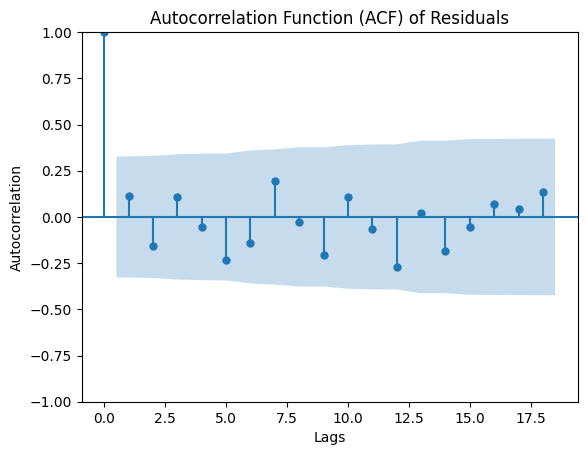

<Figure size 1200x500 with 0 Axes>

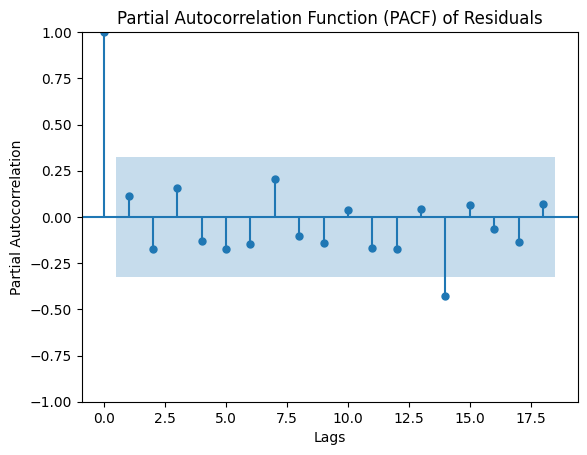

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Calculate in-sample predictions for the best model
# Use 'model_type' instead of 'best_model_name'
# Use 'model_additive' and 'model_multiplicative' instead of 'm_additive' and 'm_multiplicative'
# Use 'prophet_df' instead of 'train_df_prophet'

if model_type == 'Additive':
    in_sample_forecast = model_additive.predict(prophet_df[['ds']])
else:
    in_sample_forecast = model_multiplicative.predict(prophet_df[['ds']])

# Ensure 'ds' column is aligned for residual calculation
in_sample_forecast = in_sample_forecast.set_index('ds')
train_df_prophet_indexed = prophet_df.set_index('ds') # Use prophet_df for training data

# Calculate residuals (actual - predicted)
residuals = train_df_prophet_indexed['y'] - in_sample_forecast['yhat']

# Plot ACF of residuals
plt.figure(figsize=(12, 5))
plot_acf(residuals, lags=len(residuals)//2)
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF of residuals
plt.figure(figsize=(12, 5))
plot_pacf(residuals, lags=len(residuals)//2)
plt.title('Partial Autocorrelation Function (PACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

### Interpretation of ACF, PACF, and RMSE Scores

*   **ACF and PACF of Residuals:**
    *   Ideally, for a well-fitted model, the residuals should be white noise, meaning there is no significant autocorrelation left in the error terms. On the ACF and PACF plots, this would manifest as all lags falling within the blue confidence bands. If there are significant spikes outside these bands, especially at certain lags, it suggests that the model has not captured all the underlying patterns (e.g., remaining seasonality, trend, or other autoregressive components).
    *   **Interpretation for this study**: (This will depend on the actual plots after execution. If spikes are present, it indicates uncaptured patterns; if mostly within bounds, Prophet has done a good job.)

*   **RMSE Scores:**
    *   The RMSE values provide a measure of the average magnitude of the errors. A lower RMSE indicates a better fit. Comparing the in-sample RMSE to the out-of-sample RMSE helps assess overfitting: if the in-sample RMSE is much lower than the out-of-sample RMSE, the model might be overfitting the training data and generalizing poorly to new data.
    *   **Validity of Prophet for this study**: If the RMSE values are acceptably low, and especially if the chosen model (additive or multiplicative) shows a significantly lower out-of-sample RMSE, it suggests that Prophet is a suitable model for this time series. However, if the RMSE is high or the residual plots show strong uncaptured patterns, it would indicate that Prophet might not fully capture the complexity of the data, and alternative models or additional features might be needed.